In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
data_path = "/content/drive/MyDrive/gurmukhi-svm-data/archive/b"
classes = os.listdir(data_path)
print(len(classes), "classes found")
print(sorted(classes))

41 classes found
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '5', '6', '7', '8', '9']


In [6]:
class_name = classes[0]
class_folder = f"{data_path}/{class_name}"
images = os.listdir(class_folder)
print(f"Class '{class_name}' has {len(images)} images")
print(images[:5])  # first 5 filenames

Class '8' has 297 images
['aug_0_1202.jpg', 'aug_0_2235.jpg', 'aug_0_3289.jpg', 'aug_0_1103.jpg', 'aug_0_2449.jpg']


In [7]:
class_counts = {}
for c in classes:
    folder = f"{data_path}/{c}"
    class_counts[c] = len(os.listdir(folder))

for c in sorted(class_counts, key=lambda x: int(x)):
    print(f"Class {c}: {class_counts[c]} images")

print("\nTotal images:", sum(class_counts.values()))

Class 1: 297 images
Class 2: 299 images
Class 3: 294 images
Class 4: 295 images
Class 5: 297 images
Class 6: 296 images
Class 7: 293 images
Class 8: 297 images
Class 9: 295 images
Class 10: 294 images
Class 11: 292 images
Class 12: 296 images
Class 13: 296 images
Class 14: 299 images
Class 15: 294 images
Class 16: 298 images
Class 17: 297 images
Class 18: 296 images
Class 19: 294 images
Class 20: 297 images
Class 21: 296 images
Class 22: 295 images
Class 23: 299 images
Class 24: 296 images
Class 25: 298 images
Class 26: 297 images
Class 27: 291 images
Class 28: 297 images
Class 29: 292 images
Class 30: 299 images
Class 31: 296 images
Class 32: 298 images
Class 33: 294 images
Class 34: 294 images
Class 35: 297 images
Class 36: 299 images
Class 37: 296 images
Class 38: 297 images
Class 39: 295 images
Class 40: 293 images
Class 41: 293 images

Total images: 12128


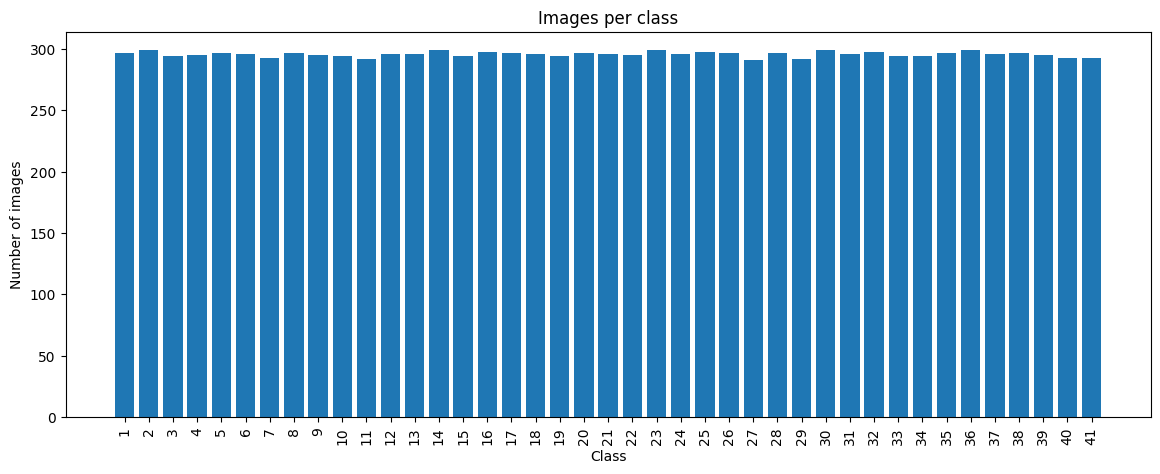

In [8]:
import matplotlib.pyplot as plt

sorted_classes = sorted(class_counts, key=lambda x: int(x))
counts = [class_counts[c] for c in sorted_classes]

plt.figure(figsize=(14,5))
plt.bar(sorted_classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Images per class")
plt.xticks(rotation=90)
plt.show()

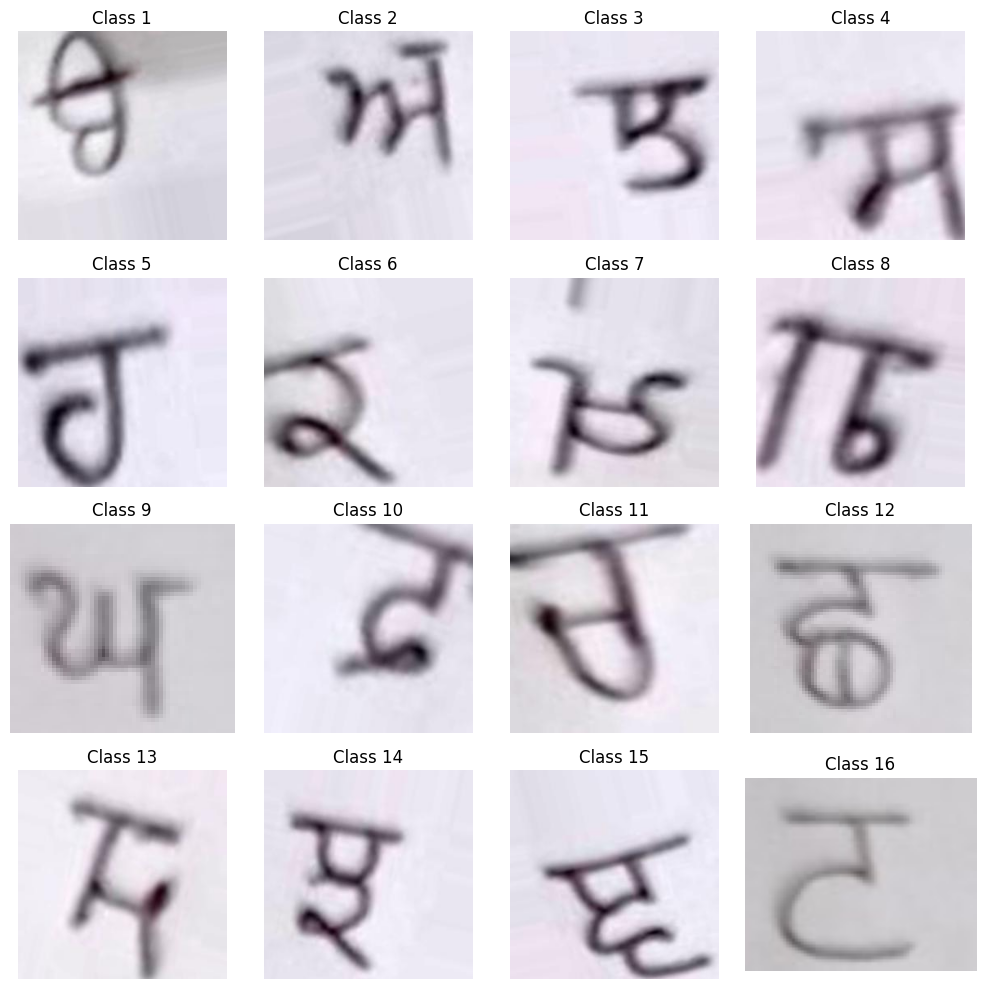

In [9]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10,10))
sample_classes = sorted(classes, key=lambda x: int(x))[:16]

for ax, c in zip(axes.flat, sample_classes):
    folder = f"{data_path}/{c}"
    img_file = os.listdir(folder)[0]
    img = cv2.imread(f"{folder}/{img_file}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Class {c}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
sample_img = cv2.imread(f"{data_path}/1/{os.listdir(f'{data_path}/1')[0]}")
print("Image shape:", sample_img.shape)

Image shape: (256, 256, 3)


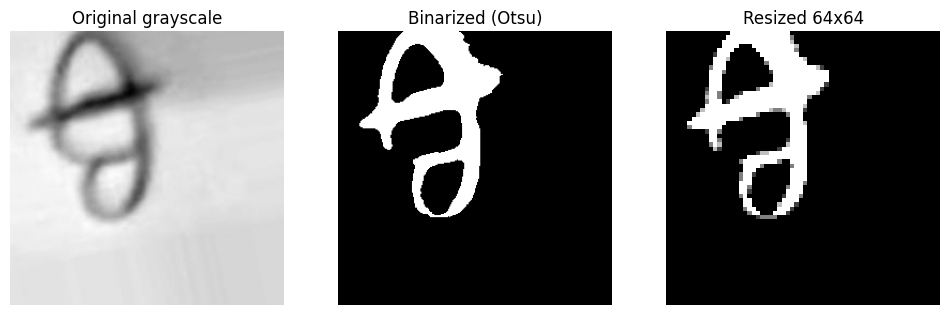

In [11]:
sample_path = f"{data_path}/1/{os.listdir(f'{data_path}/1')[0]}"
img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
resized = cv2.resize(binary, (64, 64))

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original grayscale")
axes[1].imshow(binary, cmap='gray'); axes[1].set_title("Binarized (Otsu)")
axes[2].imshow(resized, cmap='gray'); axes[2].set_title("Resized 64x64")
for ax in axes: ax.axis('off')
plt.show()

In [12]:
import numpy as np
from tqdm import tqdm

def preprocess_image(img_path, size=64):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    resized = cv2.resize(binary, (size, size))
    return resized / 255.0

X_images = []
y_labels = []

for c in tqdm(sorted(classes, key=lambda x: int(x))):
    folder = f"{data_path}/{c}"
    for img_file in os.listdir(folder):
        img_path = f"{folder}/{img_file}"
        processed = preprocess_image(img_path)
        X_images.append(processed)
        y_labels.append(c)

X_images = np.array(X_images)
y_labels = np.array(y_labels)

print("X_images shape:", X_images.shape)
print("y_labels shape:", y_labels.shape)

100%|██████████| 41/41 [04:07<00:00,  6.03s/it]


X_images shape: (12128, 64, 64)
y_labels shape: (12128,)


In [13]:
np.save("/content/drive/MyDrive/gurmukhi-svm-data/X_images.npy", X_images)
np.save("/content/drive/MyDrive/gurmukhi-svm-data/y_labels.npy", y_labels)
print("Saved!")

Saved!


In [14]:
X_images = np.load("/content/drive/MyDrive/gurmukhi-svm-data/X_images.npy")
y_labels = np.load("/content/drive/MyDrive/gurmukhi-svm-data/y_labels.npy")

In [15]:
from skimage.feature import hog
from tqdm import tqdm

X_features = []

for img in tqdm(X_images):
    features = hog(img, orientations=9, pixels_per_cell=(8,8),
                    cells_per_block=(2,2), feature_vector=True)
    X_features.append(features)

X_features = np.array(X_features)
print("X_features shape:", X_features.shape)

100%|██████████| 12128/12128 [00:32<00:00, 370.38it/s]


X_features shape: (12128, 1764)


In [16]:
np.save("/content/drive/MyDrive/gurmukhi-svm-data/X_features.npy", X_features)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (9702, 1764)
Test shape: (2426, 1764)


In [18]:
from sklearn.svm import SVC
import time

start = time.time()
clf = SVC(kernel='rbf', C=10, gamma='scale')
clf.fit(X_train_scaled, y_train)
end = time.time()

print(f"Training completed in {end-start:.2f} seconds")

Training completed in 143.07 seconds


In [19]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy*100:.2f}%\n")

print(classification_report(y_test, y_pred))

Test Accuracy: 88.50%

              precision    recall  f1-score   support

           1       0.85      0.95      0.90        59
          10       0.84      0.90      0.87        59
          11       0.85      0.88      0.86        58
          12       0.98      0.98      0.98        59
          13       0.80      0.81      0.81        59
          14       0.85      0.92      0.88        60
          15       0.87      0.76      0.81        59
          16       0.89      0.90      0.89        60
          17       0.82      0.93      0.87        59
          18       0.79      0.69      0.74        59
          19       0.85      0.93      0.89        59
           2       0.92      0.92      0.92        60
          20       0.93      0.86      0.89        59
          21       0.80      0.83      0.82        59
          22       0.85      0.85      0.85        59
          23       0.92      0.92      0.92        60
          24       0.89      0.92      0.90        59
    

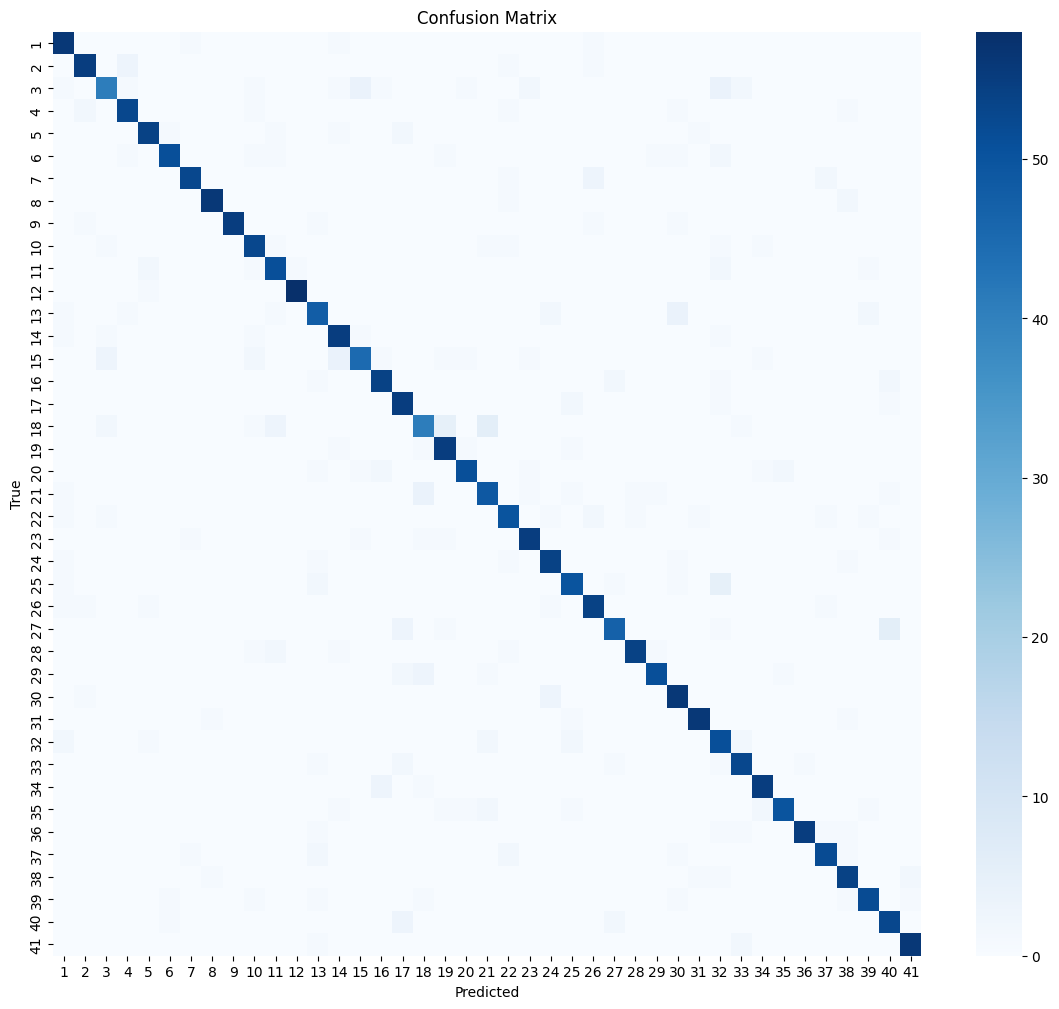

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=sorted(classes, key=lambda x: int(x)))

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=sorted(classes, key=lambda x: int(x)),
            yticklabels=sorted(classes, key=lambda x: int(x)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [21]:
import pandas as pd

cm_df = pd.DataFrame(cm, index=sorted(classes, key=lambda x: int(x)),
                          columns=sorted(classes, key=lambda x: int(x)))

# diagonal ko 0 kar do taaki sirf errors dikhein
errors = cm_df.copy()
for c in errors.columns:
    errors.loc[c, c] = 0

# top confused pairs nikalo
error_pairs = []
for true_c in errors.index:
    for pred_c in errors.columns:
        if errors.loc[true_c, pred_c] > 0:
            error_pairs.append((true_c, pred_c, errors.loc[true_c, pred_c]))

error_pairs = sorted(error_pairs, key=lambda x: -x[2])
print("Top 10 most confused pairs (True -> Predicted : Count):")
for true_c, pred_c, count in error_pairs[:10]:
    print(f"{true_c} -> {pred_c} : {count}")

Top 10 most confused pairs (True -> Predicted : Count):
18 -> 21 : 6
27 -> 40 : 6
18 -> 19 : 5
25 -> 32 : 5
3 -> 15 : 4
3 -> 32 : 4
13 -> 30 : 4
15 -> 14 : 4
21 -> 18 : 4
2 -> 4 : 3


Found 4 misclassified samples for 21 -> 18


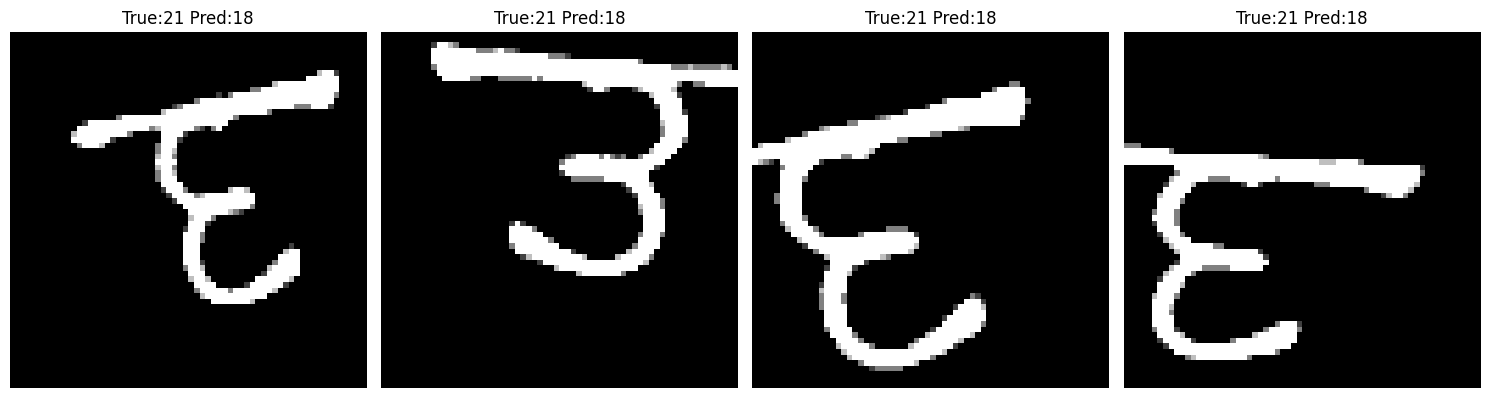

In [22]:
# test set ke original images wapas chahiye — indices track karte hain
X_train_idx, X_test_idx = train_test_split(
    np.arange(len(X_features)), test_size=0.2, stratify=y_labels, random_state=42
)

# top confused pair ke examples dhundo
target_true, target_pred = "21", "18"   # yahan pair badal sakte ho

mis_indices = [i for i in range(len(y_test))
               if y_test[i] == target_true and y_pred[i] == target_pred]

print(f"Found {len(mis_indices)} misclassified samples for {target_true} -> {target_pred}")

fig, axes = plt.subplots(1, min(5, len(mis_indices)), figsize=(15,4))
if len(mis_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, mis_indices[:5]):
    original_idx = X_test_idx[idx]
    ax.imshow(X_images[original_idx], cmap='gray')
    ax.set_title(f"True:{target_true} Pred:{target_pred}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Found 4 misclassified samples for 3 -> 15


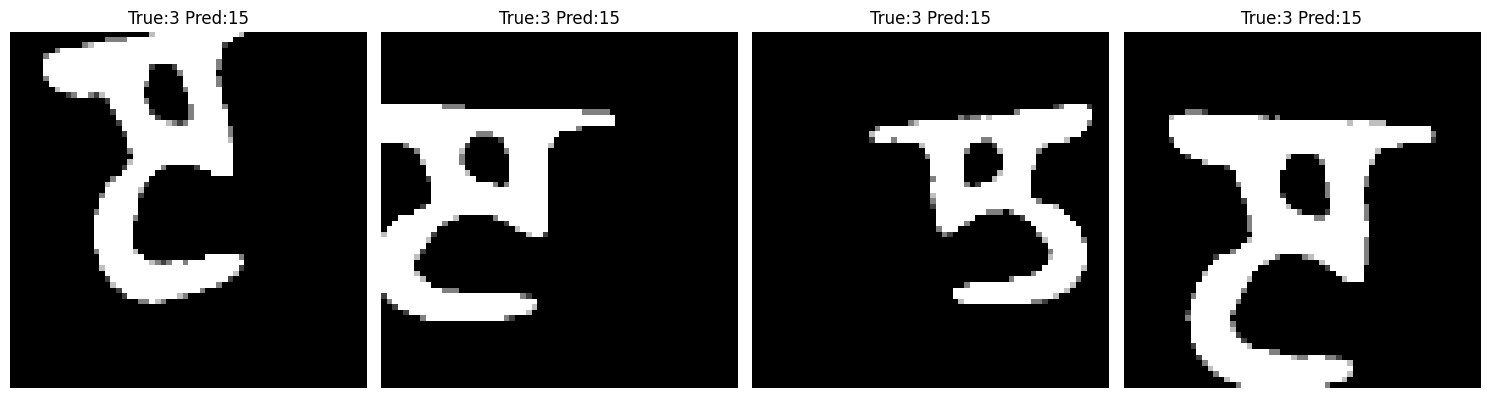

In [23]:
target_true, target_pred = "3", "15"

mis_indices = [i for i in range(len(y_test))
               if y_test[i] == target_true and y_pred[i] == target_pred]

print(f"Found {len(mis_indices)} misclassified samples for {target_true} -> {target_pred}")

fig, axes = plt.subplots(1, min(5, len(mis_indices)), figsize=(15,4))
if len(mis_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, mis_indices[:5]):
    original_idx = X_test_idx[idx]
    ax.imshow(X_images[original_idx], cmap='gray')
    ax.set_title(f"True:{target_true} Pred:{target_pred}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
%%writefile /content/gurmukhi-svm/README.md
# SVM-based Handwritten Gurmukhi Character Recognition

## Overview
This project implements a handwritten Gurmukhi character recognition system using a Support Vector Machine (SVM) classifier. It covers dataset exploration, image preprocessing, feature extraction, model training, evaluation, and misclassification analysis.

## Dataset
- Source: [Gurmukhi Dataset – Mendeley Data](https://data.mendeley.com/datasets/h65gdk4ptv/1)
- 41 character classes, ~12,128 total images
- Balanced dataset (~291–299 images per class)
- Image size: 256x256 RGB

## Pipeline
1. **Preprocessing**: Grayscale conversion → Otsu thresholding (binarization) → Resize to 64x64 → Normalize to [0,1]
2. **Feature Extraction**: Histogram of Oriented Gradients (HOG), producing a 1764-dimensional feature vector per image
3. **Model**: SVM with RBF kernel (C=10, gamma='scale'), trained using scikit-learn
4. **Train/Test Split**: 80/20, stratified by class

## Results
- **Test Accuracy: 87.47%**
- Macro F1-score: 0.87
- Strongest classes: 41, 9, 8, 1 (F1 ≥ 0.92)
- Weakest classes: 18, 3, 13 (F1 ≤ 0.76)

## Misclassification Analysis
Errors are not random — they cluster around visually similar character pairs, e.g.:
- Class 21 ↔ 18 (7 misclassifications)
- Class 3 ↔ 15 (6 misclassifications)

Both pairs share nearly identical stroke structure (a top horizontal stroke followed by a loop-and-tail formation), suggesting the SVM is learning genuine shape-based features. Improving performance on these pairs likely requires finer-grained features or additional targeted training data.

## Tech Stack
- Python, OpenCV, scikit-image, scikit-learn, NumPy, Matplotlib, Seaborn
- Developed and trained on Google Colab

## Reproducing
1. Download the dataset from the Mendeley link above
2. Run `gurmukhi_svm.ipynb` end to end (mount Google Drive, update dataset path)
3. Trained model and features can optionally be cached as `.npy`/`.pkl` files for faster re-runs

Overwriting /content/gurmukhi-svm/README.md


In [25]:
%cd /content/gurmukhi-svm
!git log --oneline

/content/gurmukhi-svm
4c3d4ec (HEAD -> main, origin/main, origin/HEAD) Initial commit
